# CMT307 Applied Machine Learning — ASHRAE Great Energy Predictor III

**Cardiff University | Spring 2025/26 | Task 9: Energy Usage Prediction**

---

| | |
|---|---|
| **Name** | Tanisha |
| **Role** | Person 3 — Weather Data Audit |
| **Notebook** | `Tanisha_Weather_Audit.ipynb` |

---

## Sprint 1 — Data Exploration & Audit (`weather_train.csv` / `weather_test.csv`)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
train = pd.read_csv("C:/Users/TANISHA/Downloads/ashrae-energy-prediction/weather_train.csv")
test = pd.read_csv("C:/Users/TANISHA/Downloads/ashrae-energy-prediction/weather_test.csv")

# Convert timestamp to datetime
train["timestamp"] = pd.to_datetime(train["timestamp"])
test["timestamp"] = pd.to_datetime(test["timestamp"])

In [2]:
# Shape comparison
print("Train shape:", train.shape)
print("Test shape:", test.shape)

# Date range
print("\nTrain date range:")
print(train["timestamp"].min(), "to", train["timestamp"].max())

print("\nTest date range:")
print(test["timestamp"].min(), "to", test["timestamp"].max())

Train shape: (139773, 9)
Test shape: (277243, 9)

Train date range:
2016-01-01 00:00:00 to 2016-12-31 23:00:00

Test date range:
2017-01-01 00:00:00 to 2018-12-31 23:00:00


In [3]:
# Function to calculate missing %
def missing_percentage(df):
    return (df.isnull().sum() / len(df)) * 100

# Calculate missing %
train_missing = missing_percentage(train)
test_missing = missing_percentage(test)

# Combine side by side
missing_df = pd.DataFrame({
    "Train Missing %": train_missing,
    "Test Missing %": test_missing
})

print("\nMissing Values Comparison:")
print(missing_df)


Missing Values Comparison:
                    Train Missing %  Test Missing %
site_id                    0.000000        0.000000
timestamp                  0.000000        0.000000
air_temperature            0.039350        0.037512
cloud_coverage            49.489529       50.658808
dew_temperature            0.080845        0.117947
precip_depth_1_hr         35.979052       34.478057
sea_level_pressure         7.596603        7.670167
wind_direction             4.484414        4.461790
wind_speed                 0.217496        0.165919


In [4]:
# Unique site count
print("\nTrain sites:", train["site_id"].nunique())
print("Test sites:", test["site_id"].nunique())

# Check missing sites
train_sites = set(train["site_id"].unique())
test_sites = set(test["site_id"].unique())

print("\nSites missing in test:", train_sites - test_sites)
print("Sites missing in train:", test_sites - train_sites)


Train sites: 16
Test sites: 16

Sites missing in test: set()
Sites missing in train: set()


In [5]:
# Check missing timestamps per site in weather_train
print("Timestamp gap check for weather_train:")
for site in train["site_id"].unique():
    site_data = train[train["site_id"] == site].sort_values("timestamp")

    # Calculate time difference between consecutive rows
    time_diff = site_data["timestamp"].diff()

    # Check gaps larger than 1 hour
    gaps = time_diff[time_diff > pd.Timedelta(hours=1)]

    if len(gaps) > 0:
        print(f"Train - Site {site} has missing timestamps")

# Check missing timestamps per site in weather_test
print("\nTimestamp gap check for weather_test:")
for site in test["site_id"].unique():
    site_data = test[test["site_id"] == site].sort_values("timestamp")

    # Calculate time difference between consecutive rows
    time_diff = site_data["timestamp"].diff()

    # Check gaps larger than 1 hour
    gaps = time_diff[time_diff > pd.Timedelta(hours=1)]

    if len(gaps) > 0:
        print(f"Test - Site {site} has missing timestamps")

Timestamp gap check for weather_train:
Train - Site 1 has missing timestamps
Train - Site 2 has missing timestamps
Train - Site 3 has missing timestamps
Train - Site 5 has missing timestamps
Train - Site 6 has missing timestamps
Train - Site 7 has missing timestamps
Train - Site 9 has missing timestamps
Train - Site 10 has missing timestamps
Train - Site 11 has missing timestamps
Train - Site 12 has missing timestamps
Train - Site 13 has missing timestamps
Train - Site 14 has missing timestamps
Train - Site 15 has missing timestamps

Timestamp gap check for weather_test:
Test - Site 1 has missing timestamps
Test - Site 3 has missing timestamps
Test - Site 4 has missing timestamps
Test - Site 5 has missing timestamps
Test - Site 6 has missing timestamps
Test - Site 7 has missing timestamps
Test - Site 9 has missing timestamps
Test - Site 10 has missing timestamps
Test - Site 11 has missing timestamps
Test - Site 12 has missing timestamps
Test - Site 13 has missing timestamps
Test - Site

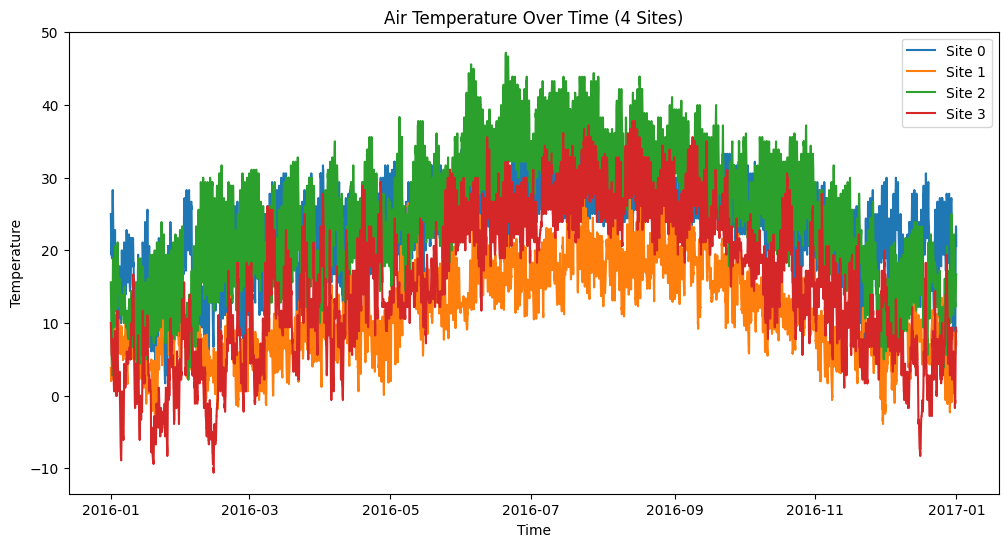

In [6]:
# Plot for first 4 sites
sites = train["site_id"].unique()[:4]

plt.figure(figsize=(12, 6))

for site in sites:
    site_data = train[train["site_id"] == site]
    plt.plot(site_data["timestamp"], site_data["air_temperature"], label=f"Site {site}")

plt.legend()
plt.title("Air Temperature Over Time (4 Sites)")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.show()

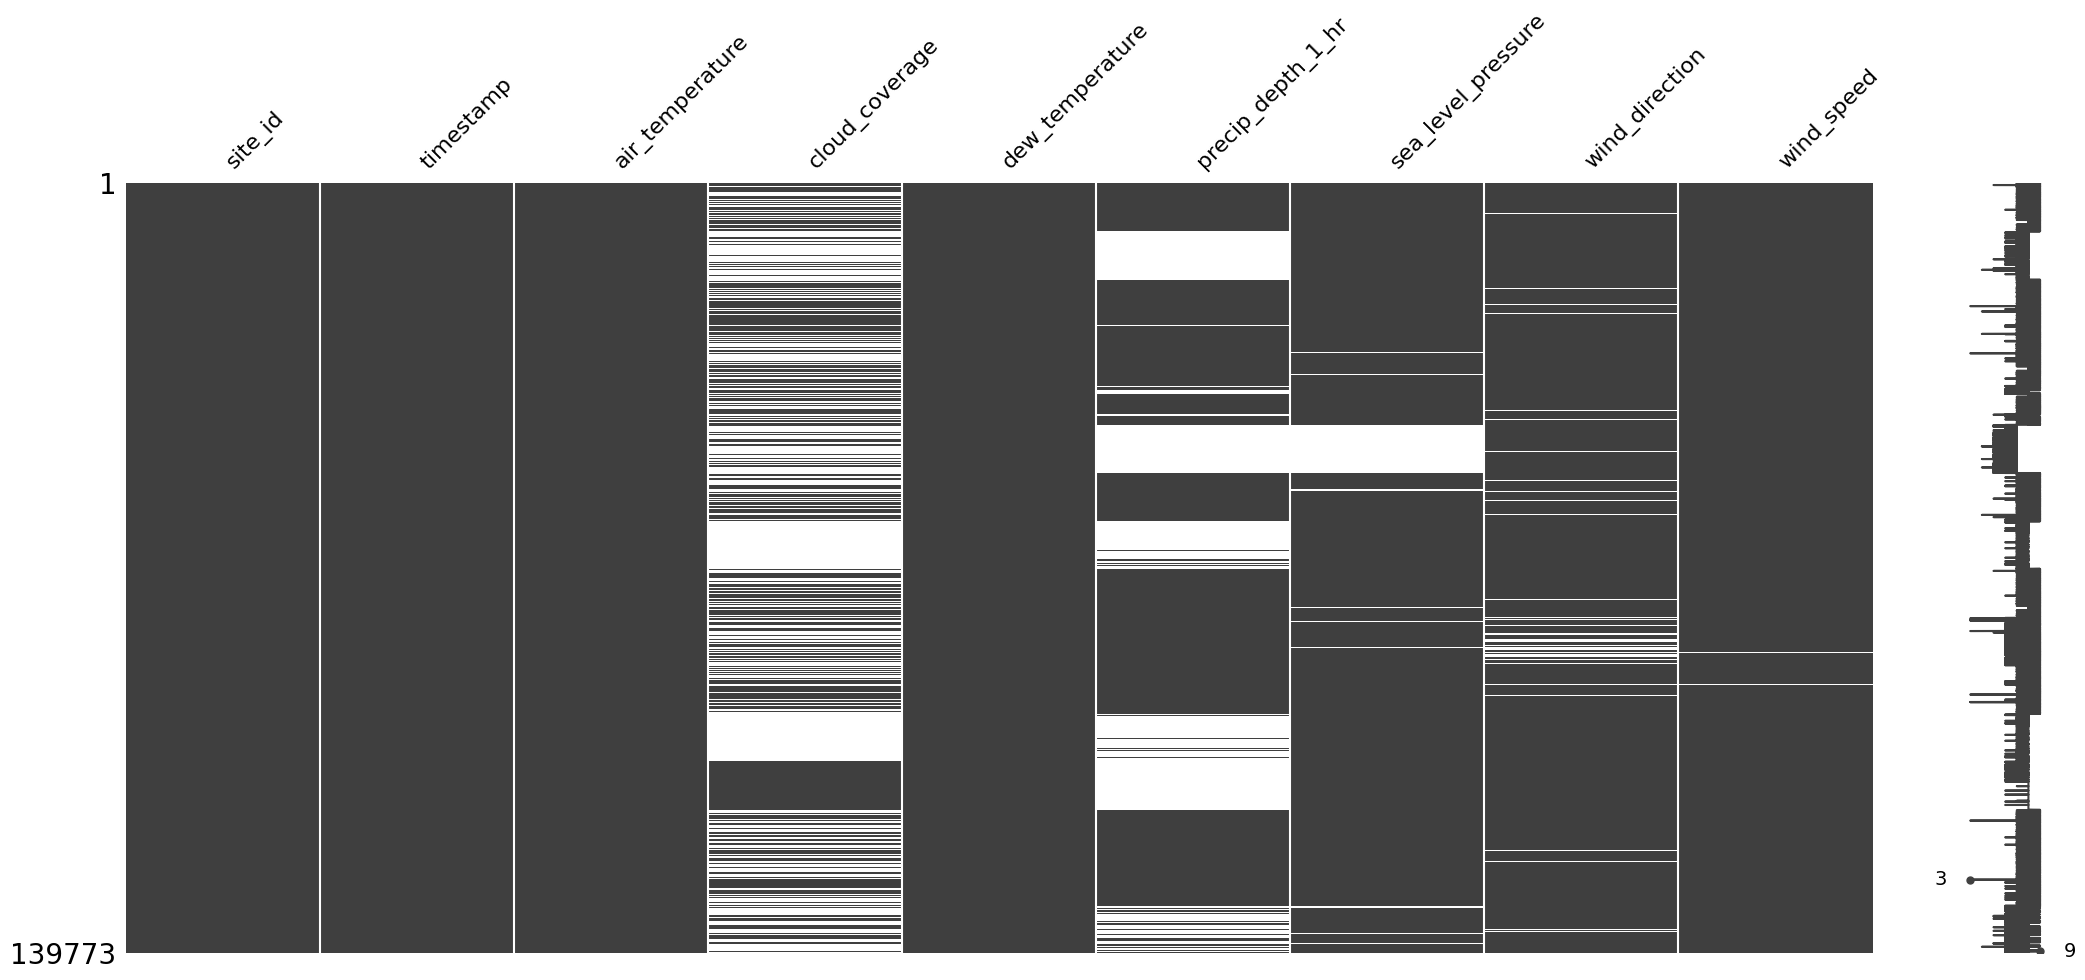

In [7]:
import missingno as msno

# Visualize missing values
msno.matrix(train)
plt.show()

## Key Findings

1. Both datasets loaded successfully:  
   **weather_train (139,773 rows)** and **weather_test (277,243 rows)**

2. Both datasets have identical structure and features, allowing direct comparison and future merging.

3. Timestamp ranges confirm expected separation:  
   **train = historical data**, **test = future data** — no data leakage risk.

4. All **16 site_ids** are present in both datasets — no missing locations.

5. Columns with missing values:
   - **cloud_coverage:** ~50% missing — large gaps due to weather station limitations
   - **precip_depth_1_hr:** ~36% missing — incomplete rainfall measurements
   - **sea_level_pressure:** ~5–10% missing — occasional sensor gaps
   - **wind_direction:** ~5–10% missing — moderate missing values
   - **air_temperature, dew_temperature, wind_speed:** <1% missing — high data quality

6. Missing values are **not randomly distributed** — they appear in structured blocks across time.

7. Missing patterns suggest:
   - Sensor unavailability
   - Site-specific recording issues
   - Time-based data gaps

8. Timestamp analysis shows missing hourly records in both train and test datasets, indicating gaps in time-series continuity.

9. Temperature trends show:
   - Clear seasonal patterns
   - Variation across different sites
   - Strong relevance for energy consumption modeling

10. Missing value heatmap confirms:
   - Concentrated missingness in specific columns
   - Non-random distribution of missing data

11. Missing weather values originate from data collection issues rather than merging errors.

---

## Sprint 2 — Weather Feature Engineering & Preprocessing

In [8]:
# Load datasets
weather_train = pd.read_csv("C:/Users/TANISHA/Downloads/ashrae-energy-prediction/weather_train.csv")
weather_test = pd.read_csv("C:/Users/TANISHA/Downloads/ashrae-energy-prediction/weather_test.csv")


In [9]:
# Convert timestamp
weather_train["timestamp"] = pd.to_datetime(weather_train["timestamp"])
weather_test["timestamp"] = pd.to_datetime(weather_test["timestamp"])

In [10]:
# Sort data by site_id and timestamp
weather_train = weather_train.sort_values(["site_id", "timestamp"]).reset_index(drop=True)
weather_test = weather_test.sort_values(["site_id", "timestamp"]).reset_index(drop=True)

In [11]:
# Define preprocessing function
def preprocess_weather(df):
    df = df.copy()

    # Interpolate air_temperature per site
    df["air_temperature"] = df.groupby("site_id")["air_temperature"].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

    # Interpolate dew_temperature per site
    df["dew_temperature"] = df.groupby("site_id")["dew_temperature"].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

    # Forward fill + backward fill cloud_coverage per site
    df["cloud_coverage"] = df.groupby("site_id")["cloud_coverage"].transform(
        lambda x: x.ffill().bfill()
    )

    # Create precipitation missing flag
    df["precip_was_missing"] = df["precip_depth_1_hr"].isna().astype(int)

    # Fill precipitation with 0
    df["precip_depth_1_hr"] = df["precip_depth_1_hr"].fillna(0)

    # Fill sea_level_pressure using 24-hour rolling median per site
    sea_level_rolling = df.groupby("site_id")["sea_level_pressure"].transform(
        lambda x: x.rolling(window=24, min_periods=1).median()
    )
    df["sea_level_pressure"] = df["sea_level_pressure"].fillna(sea_level_rolling)

    # Fallback: fill any remaining pressure values with site median
    df["sea_level_pressure"] = df.groupby("site_id")["sea_level_pressure"].transform(
        lambda x: x.fillna(x.median())
    )

    # Fill wind_direction using 24-hour rolling median per site
    wind_direction_rolling = df.groupby("site_id")["wind_direction"].transform(
        lambda x: x.rolling(window=24, min_periods=1).median()
    )
    df["wind_direction"] = df["wind_direction"].fillna(wind_direction_rolling)

    # Fallback: fill any remaining wind_direction values with site median
    df["wind_direction"] = df.groupby("site_id")["wind_direction"].transform(
        lambda x: x.fillna(x.median())
    )

    return df

In [12]:
# Apply preprocessing first
weather_train_processed = preprocess_weather(weather_train)
weather_test_processed = preprocess_weather(weather_test)

In [13]:
# Create relative_humidity and temp_diff_from_comfort
for df in [weather_train_processed, weather_test_processed]:

    # Relative humidity
    df["relative_humidity"] = 100 * (
        np.exp((17.625 * df["dew_temperature"]) / (243.04 + df["dew_temperature"])) /
        np.exp((17.625 * df["air_temperature"]) / (243.04 + df["air_temperature"]))
    )

    # Keep humidity in realistic range
    df["relative_humidity"] = df["relative_humidity"].clip(0, 100)

    # Temperature difference from comfort (21°C)
    df["temp_diff_from_comfort"] = (df["air_temperature"] - 21).abs()

In [14]:
# Define critical columns
critical_columns = [
    "air_temperature",
    "dew_temperature",
    "cloud_coverage",
    "precip_depth_1_hr",
    "sea_level_pressure",
    "wind_direction",
    "relative_humidity",
    "temp_diff_from_comfort"
]

print("Missing values in weather_train_processed:")
print(weather_train_processed[critical_columns].isnull().sum())

print("\nMissing values in weather_test_processed:")
print(weather_test_processed[critical_columns].isnull().sum())

Missing values in weather_train_processed:
air_temperature               0
dew_temperature               0
cloud_coverage            17228
precip_depth_1_hr             0
sea_level_pressure         8755
wind_direction                0
relative_humidity             0
temp_diff_from_comfort        0
dtype: int64

Missing values in weather_test_processed:
air_temperature               0
dew_temperature               0
cloud_coverage            33146
precip_depth_1_hr             0
sea_level_pressure        17241
wind_direction                0
relative_humidity             0
temp_diff_from_comfort        0
dtype: int64


In [15]:
# Check precip_was_missing flag
print(weather_train_processed[["precip_depth_1_hr", "precip_was_missing"]].head())
print(weather_test_processed[["precip_depth_1_hr", "precip_was_missing"]].head())

   precip_depth_1_hr  precip_was_missing
0                0.0                   1
1               -1.0                   0
2                0.0                   0
3                0.0                   0
4               -1.0                   0
   precip_depth_1_hr  precip_was_missing
0                0.0                   1
1                0.0                   0
2                0.0                   0
3                0.0                   0
4                0.0                   0


In [16]:
# View first few rows of processed datasets
print("\nFirst 5 rows of processed weather_train:")
print(weather_train_processed.head())

print("\nFirst 5 rows of processed weather_test:")
print(weather_test_processed.head())


First 5 rows of processed weather_train:
   site_id           timestamp  air_temperature  cloud_coverage  \
0        0 2016-01-01 00:00:00             25.0             6.0   
1        0 2016-01-01 01:00:00             24.4             6.0   
2        0 2016-01-01 02:00:00             22.8             2.0   
3        0 2016-01-01 03:00:00             21.1             2.0   
4        0 2016-01-01 04:00:00             20.0             2.0   

   dew_temperature  precip_depth_1_hr  sea_level_pressure  wind_direction  \
0             20.0                0.0              1019.7             0.0   
1             21.1               -1.0              1020.2            70.0   
2             21.1                0.0              1020.2             0.0   
3             20.6                0.0              1020.1             0.0   
4             20.0               -1.0              1020.0           250.0   

   wind_speed  precip_was_missing  relative_humidity  temp_diff_from_comfort  
0         0.0

In [17]:
import os

# Create data_processed folder if it does not exist
os.makedirs("data_processed", exist_ok=True)

# Save processed files to shared folder
weather_train_processed.to_csv("data_processed/weather_train_processed.csv", index=False)
weather_test_processed.to_csv("data_processed/weather_test_processed.csv", index=False)

print("\nSprint 2 preprocessing completed successfully!")
print("Saved files:")
print("- data_processed/weather_train_processed.csv")
print("- data_processed/weather_test_processed.csv")


Sprint 2 preprocessing completed successfully!
Saved files:
- data_processed/weather_train_processed.csv
- data_processed/weather_test_processed.csv


## Key Findings

- Applied the preprocessing pipeline correctly to both `weather_train` and `weather_test`
- Missing `air_temperature` and `dew_temperature` values were linearly interpolated per `site_id`
- `cloud_coverage` was forward-filled and backward-filled within each site
- `precip_depth_1_hr` was filled with `0`, and a new `precip_was_missing` flag was created successfully
- `sea_level_pressure` and `wind_direction` were imputed using a 24-hour rolling median with site-level median fallback
- Engineered two new features after imputation:
  - `relative_humidity`
  - `temp_diff_from_comfort`
- Final null checks were run after preprocessing and feature engineering
- Processed output files were saved to the shared `data_processed/` folder for the pipeline

---

## Sprint 3 — Model Pipeline Contribution

---

## Sprint 4 — Evaluation & Report